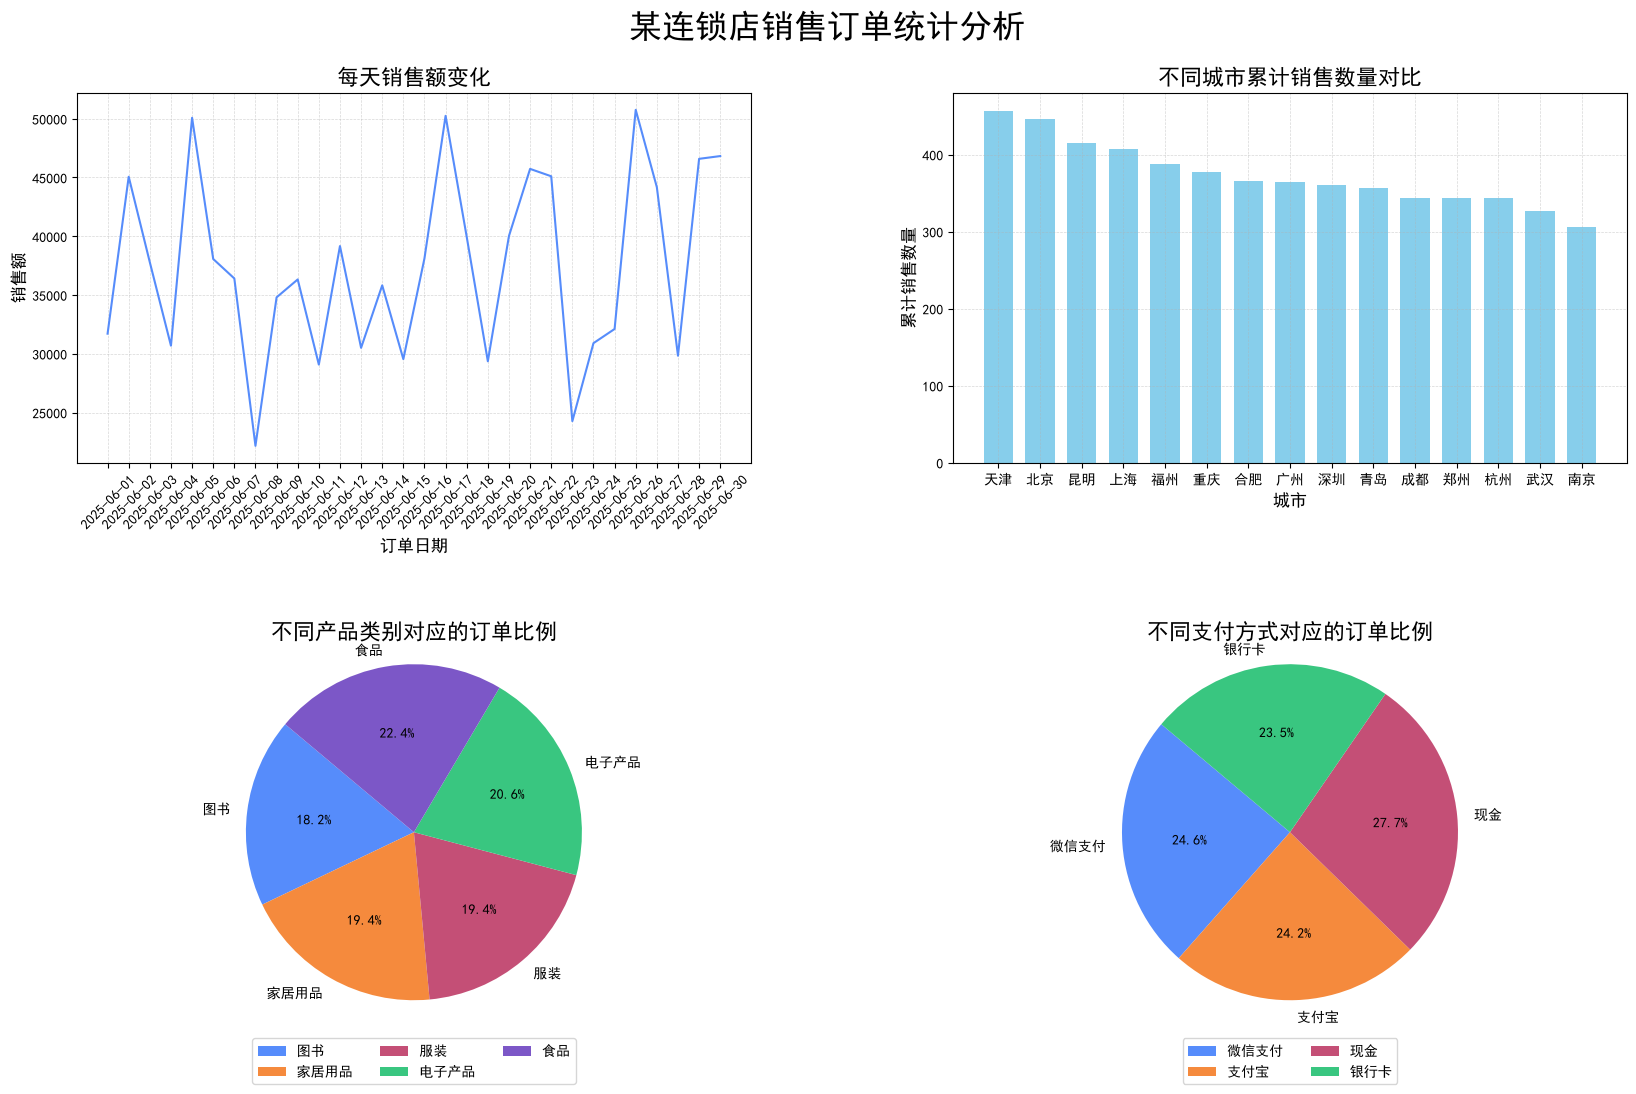

In [2]:
from matplotlib.axes import Axes
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.min_rows', 30)# 显示行数

# 显示中文
plt.rcParams['font.sans-serif'] = ['SimHei']

# 创建子图
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20,12), dpi=100)
fig.suptitle('某连锁店销售订单统计分析', fontsize=24, x=0.5, y=0.95)
fig.subplots_adjust(hspace=0.5, wspace=0.3)

# 获取子图
axes1: Axes = axes[0, 0]
axes2: Axes = axes[0, 1]
axes3: Axes = axes[1, 0]
axes4: Axes = axes[1, 1]

# 读取数据
data = pd.read_csv('data/sales.csv')


# 需求1 : 统计每天销售额的变化(折线图)
# 1.1 缺失值,异常值处理
data.isnull().sum()# 统计缺失值，都为0：表示没有缺失值；有缺失值时，会显示缺失值的个数。

# 1.1.2 填充缺失值
data['客户所在城市'] = data['客户所在城市'].ffill()# 填充缺失值,用前一个值填充

# 1.2异常值处理
# 1.2.1 查看异常值
data[data['单价'] < 0]

# 1.2.2 修复异常值
data['单价'] = data['单价'].abs()# 绝对值
# 1.2.3 数据格式处理
data["订单日期"] = data["订单日期"].str.replace("/", "-")
data

# 1.2.4 统一日期格式(数据中混有 2025/06/07 这类写法)并计算销售额
data['订单日期'] = pd.to_datetime(data['订单日期'])
data['销售额'] = data['销售数量'] * data['单价']
data

# 1.3 分组统计
day_sales = data.groupby('订单日期')['销售额'].sum()

# 组装数据
min_day = day_sales.index.min()
max_day = day_sales.index.max()

# 生成x轴数据
x = pd.date_range(min_day, max_day, freq='D') #freq='D'表示每天，freq='W'表示每周，freq='M'表示每月

# 生成y轴数据(用reindex对齐,缺失日期补0)
y = day_sales.reindex(x, fill_value=0)
# 绘制折线图
axes1.plot(x, y)# 绘制折线图
axes1.set_title('每天销售额变化', fontsize=16)# 添加子图标题
axes1.set_xlabel('订单日期', fontsize=12)# 设置x轴标签
axes1.set_ylabel('销售额', fontsize=12)# 设置y轴标签
axes1.set_xticks(x)# 设置x轴刻度
axes1.tick_params(axis='x', rotation=45)# 30个日期标签旋转45度避免重叠
axes1.grid(linestyle='--', alpha=0.5)# 添加网格




# 需求2 : 统计对比不同城市的累计销售数量 (柱状图)
# 2.1 数据处理
city_sum = data.groupby('客户所在城市')['销售数量'].sum().sort_values(ascending=False)
x_city = city_sum.index.tolist()
y_city_sales_sum = city_sum.values.tolist()
# 2.2 绘制柱状图
axes2.bar(x_city, y_city_sales_sum, color='skyblue', width=0.7)
axes2.set_title('不同城市累计销售数量对比', fontsize=16)
axes2.set_xlabel('城市', fontsize=12)
axes2.set_ylabel('累计销售数量', fontsize=12)
axes2.grid(linestyle='--', alpha=0.5)



# 需求3 : 统计不同产品类别对应的订单比例 (饼状图)
# 3.1 数据处理
type_count = data.groupby('产品类别')['产品类别'].count()
x_type = type_count.index.tolist()
y_type_count = type_count.values.tolist()

# 3.2 绘制饼状图
axes3.pie(y_type_count, labels=x_type, autopct='%1.1f%%', startangle=140, radius=1.2)
axes3.set_title('不同产品类别对应的订单比例', fontsize=16)
axes3.legend(loc='lower center',ncol=3, bbox_to_anchor=(0.5, -0.2))# 添加图例
axes3.axis('equal')  # 确保饼状图是圆的

# 需求4 : 统计不同支付方式对应的订单比例 (饼状图)
# 4.1 数据处理
pay_count = data.groupby('支付方式')['支付方式'].count()
x_pay = pay_count.index.tolist()
y_pay_count = pay_count.values.tolist()
# 4.2 绘制饼状图
axes4.pie(y_pay_count, labels=x_pay, autopct='%1.1f%%', startangle=140, radius=1.2)
axes4.set_title('不同支付方式对应的订单比例', fontsize=16)
axes4.legend(loc='lower center',ncol=2, bbox_to_anchor=(0.5, -0.2))# 添加图例
axes4.axis('equal')  # 确保饼状图是圆的


# 5. 保存图片
plt.savefig('data/sales_analysis.png')

plt.show() # 显示画布
